# Animal Classification with ResNet50 + Quantization (TensorFlow)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"rambhadrakumar","key":"3802cabd2ec9aec83dabcac171bc5da6"}'}

In [4]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle datasets download -d alessiocorrado99/animals10 --unzip -p /content/animals10')

0

In [5]:
import shutil, uuid

DATA_DIR = '/content/animals10/raw-img'

rename_map = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'
}

for italian, english in rename_map.items():
    old_path = os.path.join(DATA_DIR, italian)
    new_path = os.path.join(DATA_DIR, english)

    if os.path.exists(old_path) and os.path.exists(new_path):
        for file in os.listdir(old_path):
            src = os.path.join(old_path, file)
            dst = os.path.join(new_path, file)
            if os.path.exists(dst):
                name, ext = os.path.splitext(file)
                dst = os.path.join(new_path, f"{name}_{uuid.uuid4().hex[:6]}{ext}")
            shutil.move(src, dst)
        os.rmdir(old_path)
        print(f"Merged: {italian} → {english}")
    elif os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {italian} → {english}")

print("\nFinal folders:", sorted(os.listdir(DATA_DIR)))

Merged: cane → dog
Merged: cavallo → horse
Merged: elefante → elephant
Merged: farfalla → butterfly
Merged: gallina → chicken
Merged: gatto → cat
Merged: mucca → cow
Merged: pecora → sheep
Merged: ragno → spider
Merged: scoiattolo → squirrel

Final folders: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [6]:
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS_P1  = 5
EPOCHS_P2  = 5
NUM_CLASSES = 10
AUTOTUNE    = tf.data.AUTOTUNE

In [7]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import pathlib

data_dir = pathlib.Path(DATA_DIR)

def get_limited_dataset(data_dir, subset, split=0.2, samples_per_class=200, seed=42):
    full_ds = image_dataset_from_directory(
        data_dir,
        validation_split=split,
        subset=subset,
        seed=seed,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=1
    )
    class_names = full_ds.class_names
    limited = full_ds.filter(lambda x, y: True)

    class_datasets = []
    for i in range(NUM_CLASSES):
        class_ds = full_ds.filter(lambda x, y: tf.equal(y[0], i))
        class_ds = class_ds.take(samples_per_class)
        class_datasets.append(class_ds)

    combined = class_datasets[0]
    for ds in class_datasets[1:]:
        combined = combined.concatenate(ds)

    combined = combined.unbatch().batch(BATCH_SIZE).shuffle(500).prefetch(AUTOTUNE)
    return combined, class_names

train_ds, class_names = get_limited_dataset(DATA_DIR, 'training',   samples_per_class=150)
val_ds,   _           = get_limited_dataset(DATA_DIR, 'validation',  samples_per_class=50)

normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("Classes:", class_names)
print("Train batches:", len(list(train_ds)))
print("Val batches  :", len(list(val_ds)))

Found 52358 files belonging to 10 classes.
Using 41887 files for training.
Found 52358 files belonging to 10 classes.
Using 10471 files for validation.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Train batches: 94
Val batches  : 32


In [8]:
train_ds = train_ds.take(500)
val_ds   = val_ds.take(100)

In [9]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)

In [ ]:
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    num_show = min(8, images.shape[0])
    for i in range(num_show):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,018 (92.02 MB)

 Trainable params: 531,210 (2.03 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1
)

Epoch 1/5
     94/Unknown 39s 76ms/step - accuracy: 0.1017 - loss: 2.3153

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


94/94 ━━━━━━━━━━━━━━━━━━━━ 50s 198ms/step - accuracy: 0.0847 - loss: 2.3263 - val_accuracy: 0.1000 - val_loss: 2.4608
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.0787 - loss: 2.3220 - val_accuracy: 0.1000 - val_loss: 2.3886
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.0547 - loss: 2.3208 - val_accuracy: 0.1000 - val_loss: 2.3199
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.0833 - loss: 2.3149 - val_accuracy: 0.1000 - val_loss: 2.3052
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.0807 - loss: 2.3123 - val_accuracy: 0.1000 - val_loss: 2.3055


In [12]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2
)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.0947 - loss: 2.3039 - val_accuracy: 0.1000 - val_loss: 9.9453
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.0940 - loss: 2.3030 - val_accuracy: 0.1000 - val_loss: 8.7444
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - accuracy: 0.0933 - loss: 2.3025 - val_accuracy: 0.1000 - val_loss: 11.0187
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.0987 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 7.8632
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.1027 - loss: 2.3031 - val_accuracy: 0.1000 - val_loss: 5.7841


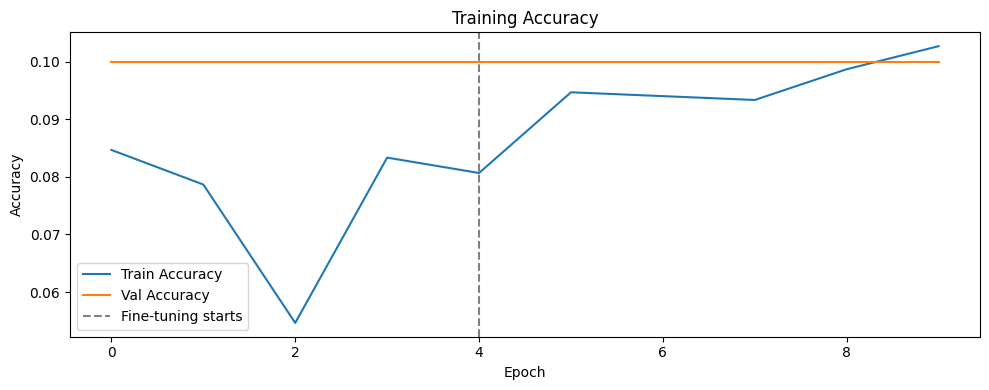

In [13]:
acc1  = history1.history['accuracy']
acc2  = history2.history['accuracy']
vacc1 = history1.history['val_accuracy']
vacc2 = history2.history['val_accuracy']

all_acc  = acc1 + acc2
all_vacc = vacc1 + vacc2

plt.figure(figsize=(10, 4))
plt.plot(all_acc,  label='Train Accuracy')
plt.plot(all_vacc, label='Val Accuracy')
plt.axvline(x=EPOCHS_P1 - 1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
orig_loss, orig_acc = model.evaluate(val_ds)
print(f"Original Model — Loss: {orig_loss:.4f}  Accuracy: {orig_acc*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.1000 - loss: 5.7841
Original Model — Loss: 5.7841  Accuracy: 10.00%


In [15]:
model.save('animal_resnet50.keras')
orig_size = os.path.getsize('animal_resnet50.keras') / (1024 * 1024)
print(f"Original Model Size: {orig_size:.2f} MB")

Original Model Size: 207.00 MB


In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open('animal_resnet50_quantized.tflite', 'wb') as f:
    f.write(tflite_model)

quant_size = os.path.getsize('animal_resnet50_quantized.tflite') / (1024 * 1024)
print(f"Quantized Model Size: {quant_size:.2f} MB")
print(f"Size Reduction      : {((orig_size - quant_size) / orig_size) * 100:.1f}%")

Saved artifact at '/tmp/tmp21u99jng'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  131921940740240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131921940741776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152256272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152256464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152254928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152254544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152257616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152258000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152259920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152260112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924152

In [17]:
interpreter = tf.lite.Interpreter(model_path='animal_resnet50_quantized.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def evaluate_tflite(interp, dataset):
    correct = 0
    total   = 0
    start   = time.time()
    for images, labels in dataset:
        for img, label in zip(images.numpy(), labels.numpy()):
            img_input = np.expand_dims(img, axis=0).astype(np.float32)
            interp.set_tensor(input_details[0]['index'], img_input)
            interp.invoke()
            output  = interp.get_tensor(output_details[0]['index'])
            pred    = np.argmax(output)
            correct += int(pred == label)
            total   += 1
    elapsed = time.time() - start
    return (correct / total) * 100, elapsed

quant_acc, quant_time = evaluate_tflite(interpreter, val_ds)
print(f"Quantized Model — Accuracy: {quant_acc:.2f}%  |  Inference Time: {quant_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized Model — Accuracy: 9.40%  |  Inference Time: 82.68s


In [18]:
start = time.time()
model.evaluate(val_ds, verbose=0)
orig_time = time.time() - start

print(f"Original  — Size: {orig_size:.2f} MB  |  Accuracy: {orig_acc*100:.2f}%  |  Time: {orig_time:.2f}s")
print(f"Quantized — Size: {quant_size:.2f} MB  |  Accuracy: {quant_acc:.2f}%  |  Time: {quant_time:.2f}s")

Original  — Size: 207.00 MB  |  Accuracy: 10.00%  |  Time: 2.76s
Quantized — Size: 23.32 MB  |  Accuracy: 9.40%  |  Time: 82.68s


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


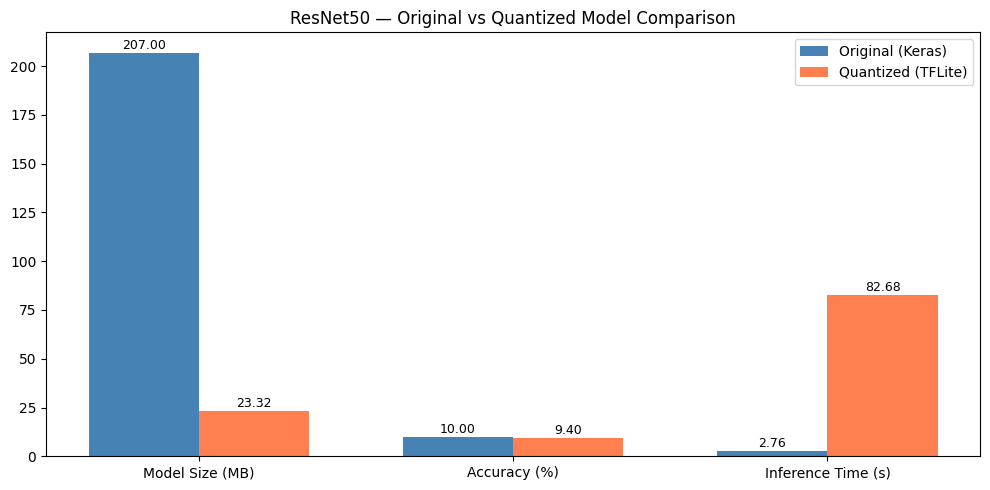

In [19]:
categories  = ['Model Size (MB)', 'Accuracy (%)', 'Inference Time (s)']
orig_vals   = [orig_size,       orig_acc * 100,  orig_time]
quant_vals  = [quant_size,      quant_acc,        quant_time]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, orig_vals,  width, label='Original (Keras)',    color='steelblue')
bars2 = ax.bar(x + width/2, quant_vals, width, label='Quantized (TFLite)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('ResNet50 — Original vs Quantized Model Comparison')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
all_preds  = []
all_labels = []

for images, labels in val_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        img_input = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        all_preds.append(np.argmax(output))
        all_labels.append(label)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix — Quantized Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

KeyboardInterrupt: 

In [22]:
from google.colab import files

files.download('animal_resnet50.keras')
files.download('animal_resnet50_quantized.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>